<p>Constantin Madalin Ismana<p>
<p>
Tomando como base este ejemplo de árboles de decisión, crea un modelo de árbol de decisión para estimar las predicciones de supervivencia de los pasajeros del Titanic.  Este es un ejemplo muy típico así que no tendrás problemas para analizarlo.

Visualiza además la matriz de confusión e indica todos los valores de las métricas que pueden utilizarse en este ejemplo.

Utiliza el dataset de Kaggle del Titanic

Compáralo con otros modelos/algoritmos ya vistos y explica tus conclusiones.

Descargar graphviz e instalarlo en Windows (aparte de pip /conda en entorno virtual de VSCode)

Puedes echar un vistazo también al capítulo 6 de "Aprende ML con Scikit-Learn, Keras y Tensorflow" de Aurélien Géron<p>

<h1>Importamos las Librerias<h1>

In [18]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import graphviz
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

<h1>Cargamos el Dataset<h1>

In [2]:
# Cargar el dataset de entrenamiento
df = pd.read_csv("train.csv")

<h1>Ahora vamos a manejar los valores nulos<h1>

In [3]:
# Manejar valores nulos 
df["Age"] = df["Age"].fillna(df["Age"].median())  # Reemplazar edad faltante con la mediana
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])  # Reemplazar puerto faltante con la moda

<h1>Codificamos las variables<h1>

In [4]:
# Codificar variables categóricas
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})  # Convertir género en valores numéricos
df["Embarked"] = df["Embarked"].map({"C": 0, "Q": 1, "S": 2})  # Convertir puerto en valores numéricos


<h1>Seleccionamos las carracteristicas mas relevantes<h1>

In [5]:
# Seleccionar características relevantes 
df.rename(columns={"Pclass": "Clase", "Sex": "Sexo", "Age": "Edad", "SibSp": "Hermanos_Conyuge", 
                   "Parch": "Padres_Hijos", "Fare": "Tarifa", "Embarked": "Puerto"}, inplace=True)

caracteristicas = ["Clase", "Sexo", "Edad", "Hermanos_Conyuge", "Padres_Hijos", "Tarifa", "Puerto"]
X = df[caracteristicas]
y = df["Survived"]  # Se mantiene "Survived" porque es la variable objetivo

<h1>Dividimos el entrenamiento y prueba<h1>

In [6]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h1>Entrenamos el modelo de arbol<h1>

In [7]:
# Entrenar el modelo de árbol de decisión con una profundidad limitada para mejor visualización
clf = DecisionTreeClassifier(random_state=42, max_depth=4)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

<h1>Realizamos las predicciones<h1>

In [8]:
# Realizar predicciones
y_pred = clf.predict(X_test)

<h1>Calculamos las metricas de evaluacion<h1>

In [9]:
# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

<h1>Monstramos los resultados que nos dan<h1>

In [10]:
# Mostrar resultados
print(f"Exactitud del modelo: {accuracy:.4f}")
print("\nReporte de clasificación:\n", report)
print("\nMatriz de confusión:\n", conf_matrix)

Exactitud del modelo: 0.7989

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.78      0.91      0.84       105
           1       0.84      0.64      0.72        74

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179


Matriz de confusión:
 [[96  9]
 [27 47]]


<h1>Visualizamos la matriz de confusion con un mapa de calor<h1>

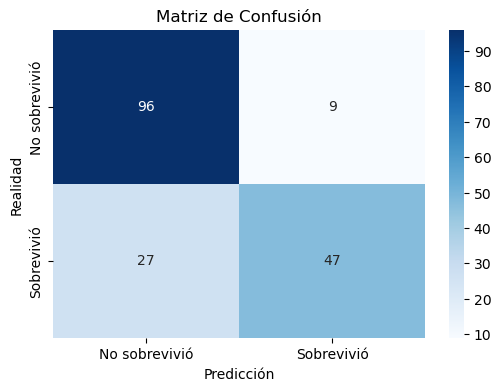

In [11]:
# Visualizar la matriz de confusión con un mapa de calor
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No sobrevivió", "Sobrevivió"], yticklabels=["No sobrevivió", "Sobrevivió"])
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.title("Matriz de Confusión")
plt.show()

<h1>Vemos la importancia de las variables<h1>

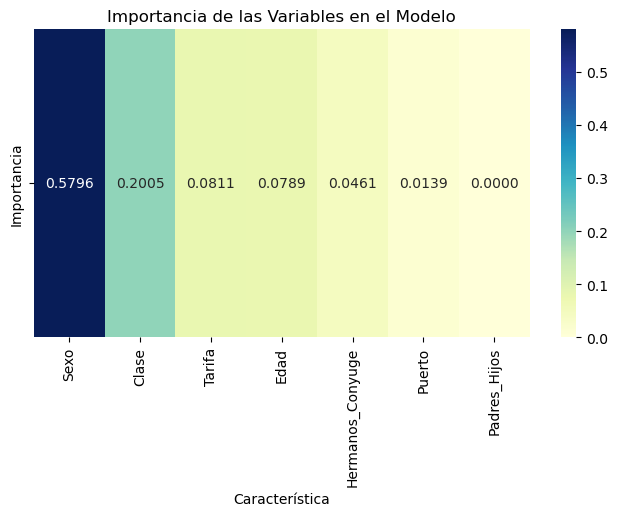

In [12]:
# Visualizar la importancia de las variables con un mapa de calor
importances = pd.DataFrame({"Característica": caracteristicas, "Importancia": clf.feature_importances_}).sort_values(by="Importancia", ascending=False)

plt.figure(figsize=(8,4))
sns.heatmap(importances.set_index("Característica").T, cmap="YlGnBu", annot=True, fmt=".4f")
plt.title("Importancia de las Variables en el Modelo")
plt.show()

<h1>Vemos el arbol de decision con Matplotlib<h1>

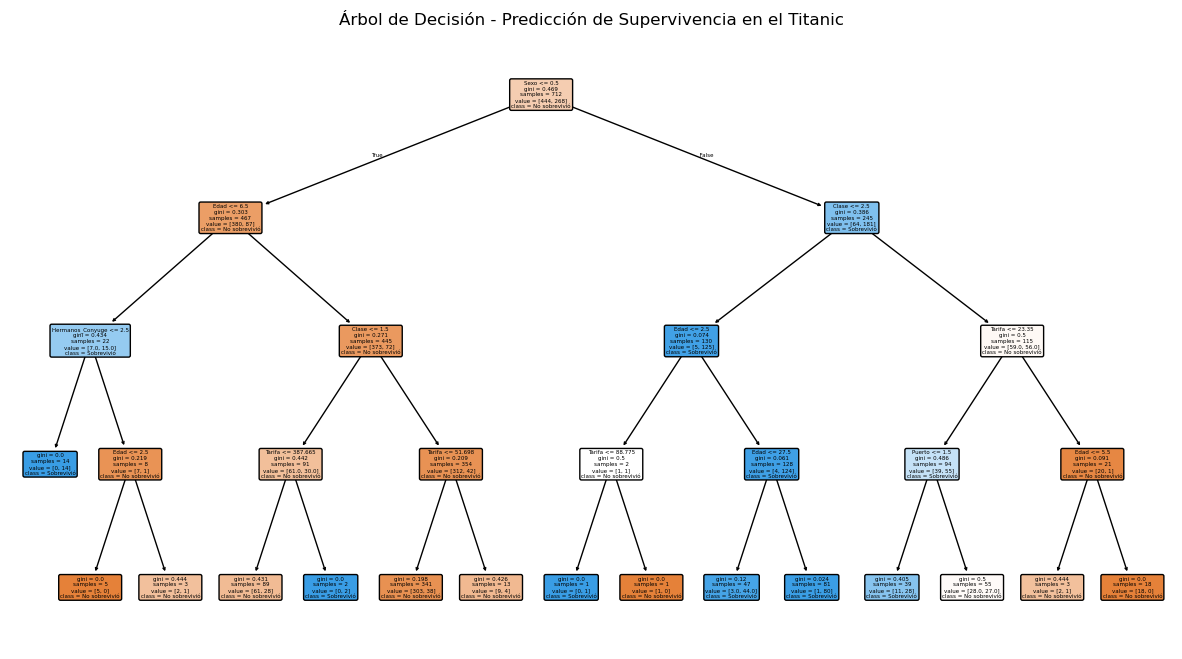

In [13]:

# Visualizar el árbol de decisión con Matplotlib
plt.figure(figsize=(15,8))
plot_tree(clf, feature_names=caracteristicas, class_names=["No sobrevivió", "Sobrevivió"], filled=True, rounded=True)
plt.title("Árbol de Decisión - Predicción de Supervivencia en el Titanic")
plt.show()

<h1>Vemos el arbol de decision con Graphviz<h1>

In [14]:
# Visualizar el árbol de decisión con Graphviz
dot_data = export_graphviz(clf, out_file=None, 
                           feature_names=caracteristicas,  
                           class_names=["No sobrevivió", "Sobrevivió"],  
                           filled=True, rounded=True, special_characters=True)  

graph = graphviz.Source(dot_data)  
graph.render("titanic_tree")  # Guarda el árbol como un archivo PDF
graph.view()  # Muestra el árbol interactivo

'titanic_tree.pdf'

<h1>Modelo de KNN<h1>

Exactitud del modelo KNN: 0.7207

Reporte de clasificación KNN:
               precision    recall  f1-score   support

           0       0.72      0.85      0.78       105
           1       0.71      0.54      0.62        74

    accuracy                           0.72       179
   macro avg       0.72      0.69      0.70       179
weighted avg       0.72      0.72      0.71       179


Matriz de confusión KNN:
 [[89 16]
 [34 40]]


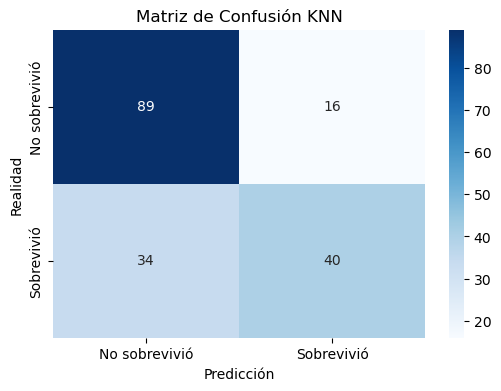

In [15]:
# Entrenar el modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Realizar predicciones
y_pred_knn = knn.predict(X_test)

# Calcular métricas de evaluación
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

# Mostrar resultados
print(f"Exactitud del modelo KNN: {accuracy_knn:.4f}")
print("\nReporte de clasificación KNN:\n", report_knn)
print("\nMatriz de confusión KNN:\n", conf_matrix_knn)

# Visualizar la matriz de confusión con un mapa de calor
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_knn, annot=True, fmt="d", cmap="Blues", xticklabels=["No sobrevivió", "Sobrevivió"], yticklabels=["No sobrevivió", "Sobrevivió"])
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.title("Matriz de Confusión KNN")
plt.show()

<h1>Modelo de Regresion Logistica<h1>

Exactitud del modelo de Regresión Logística: 0.8045

Reporte de clasificación de Regresión Logística:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179


Matriz de confusión de Regresión Logística:
 [[90 15]
 [20 54]]


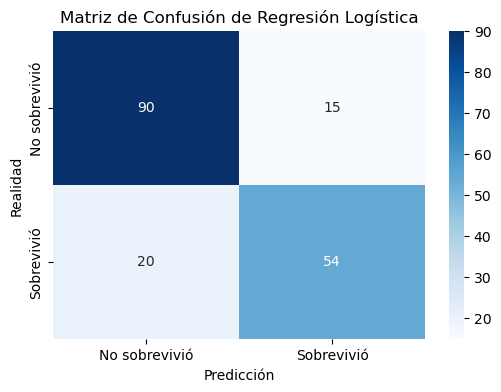

In [19]:
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo de Regresión Logística con más iteraciones
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Realizar predicciones
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Calcular métricas de evaluación
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
report_log_reg = classification_report(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Mostrar resultados
print(f"Exactitud del modelo de Regresión Logística: {accuracy_log_reg:.4f}")
print("\nReporte de clasificación de Regresión Logística:\n", report_log_reg)
print("\nMatriz de confusión de Regresión Logística:\n", conf_matrix_log_reg)

# Visualizar la matriz de confusión con un mapa de calor
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt="d", cmap="Blues", xticklabels=["No sobrevivió", "Sobrevivió"], yticklabels=["No sobrevivió", "Sobrevivió"])
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.title("Matriz de Confusión de Regresión Logística")
plt.show()

<h1>Modelo de SGD<h1>

Exactitud del modelo SGD: 0.8101

Reporte de clasificación SGD:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83       105
           1       0.74      0.82      0.78        74

    accuracy                           0.81       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.82      0.81      0.81       179


Matriz de confusión SGD:
 [[84 21]
 [13 61]]


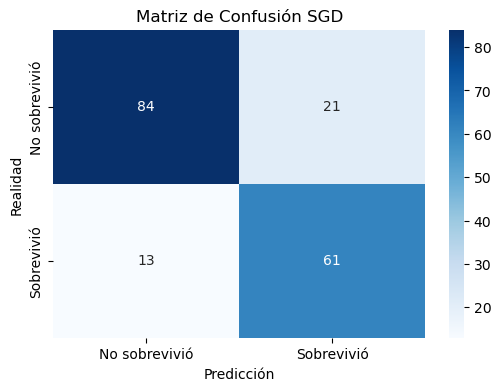

In [21]:
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo de SGDClassifier
sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3)
sgd_clf.fit(X_train_scaled, y_train)

# Realizar predicciones
y_pred_sgd = sgd_clf.predict(X_test_scaled)

# Calcular métricas de evaluación
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)
report_sgd = classification_report(y_test, y_pred_sgd)
conf_matrix_sgd = confusion_matrix(y_test, y_pred_sgd)

# Mostrar resultados
print(f"Exactitud del modelo SGD: {accuracy_sgd:.4f}")
print("\nReporte de clasificación SGD:\n", report_sgd)
print("\nMatriz de confusión SGD:\n", conf_matrix_sgd)

# Visualizar la matriz de confusión con un mapa de calor
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_sgd, annot=True, fmt="d", cmap="Blues", xticklabels=["No sobrevivió", "Sobrevivió"], yticklabels=["No sobrevivió", "Sobrevivió"])
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.title("Matriz de Confusión SGD")
plt.show()

<h1>Modelo de Naives Bayes<h1>

Exactitud del modelo Naive Bayes: 0.7765

Reporte de clasificación Naive Bayes:
               precision    recall  f1-score   support

           0       0.83      0.78      0.80       105
           1       0.71      0.77      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179


Matriz de confusión Naive Bayes:
 [[82 23]
 [17 57]]


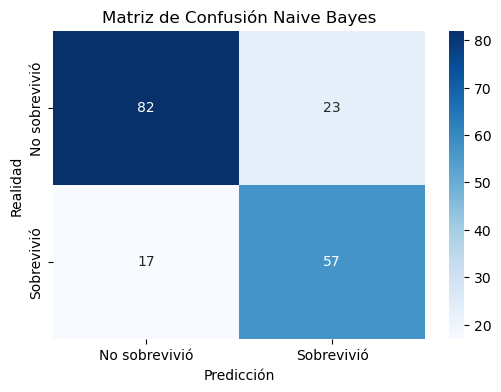

In [22]:
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo de Naive Bayes
nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)

# Realizar predicciones
y_pred_nb = nb_clf.predict(X_test_scaled)

# Calcular métricas de evaluación
accuracy_nb = accuracy_score(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

# Mostrar resultados
print(f"Exactitud del modelo Naive Bayes: {accuracy_nb:.4f}")
print("\nReporte de clasificación Naive Bayes:\n", report_nb)
print("\nMatriz de confusión Naive Bayes:\n", conf_matrix_nb)

# Visualizar la matriz de confusión con un mapa de calor
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_nb, annot=True, fmt="d", cmap="Blues", xticklabels=["No sobrevivió", "Sobrevivió"], yticklabels=["No sobrevivió", "Sobrevivió"])
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.title("Matriz de Confusión Naive Bayes")
plt.show()

<p>El mejor modelo que nos da es el SGD porque nos da 0,81 de precision<p>